# SuperSimpleNet MVTec Head Fine-Tune

Гипотеза: после базового unsupervised-обучения SuperSimpleNet на нормальных MVTec-изображениях имеет смысл отдельно дообучать головы на небольшой порции реальных дефектов.

Почему именно так:
- В оригинальной SuperSimpleNet классификационная голова отвечает за image-level score и должна ловить глобальный контекст, а сегментационная голова отвечает за карту аномалий.
- В статье про режимы обучения SuperSimpleNet явно поддерживает weak / mixed / fully supervised режимы: image-level дефекты могут учить detection/classification ветку, а маски позволяют доучивать segmentation ветку.
- Поэтому ниже сравниваются три состояния одной и той же базовой модели: до fine-tune, после fine-tune только classification head, после fine-tune всего `segdec` блока на масках.

Важно: это не официальный MVTec-протокол, потому что часть `test` используется как имитация накопленных продовых дефектов для fine-tune. Для проверки гипотезы это полезнее: мы проверяем, помогает ли отдельная адаптация голов, не смешивая train/fine-tune/holdout.

In [1]:
import copy
import csv
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

from anomalib.models.image.supersimplenet.loss import SSNLoss
from anomalib.models.image.supersimplenet.torch_model import SupersimplenetModel

c:\Users\AERO\Desktop\master_work\FastFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


random_seed = 42
seed_everything(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

cuda
NVIDIA GeForce RTX 3070 Ti Laptop GPU


## Конфигурация эксперимента

In [ ]:
dataset_path = Path("datasets") / "MVTecAD"
class_name = "hazelnut"
defect_groups = None
image_size = 256

experiment_name = "mvtec_head_finetune"
log_dir = Path("../experiments") / class_name / experiment_name
log_dir.mkdir(parents=True, exist_ok=True)

base_model_path = Path("../experiments") / class_name / "finetuned_ssn" / "trained_model.pth"
reuse_existing_base_model = False
force_retrain_base_model = False
train_base_if_missing = True

num_base_epochs = 70
base_batch_size = 10
base_learning_rate = 1e-4
base_weight_decay = 1e-5
base_val_fraction = 0.15
base_early_stopping_patience = 10

head_finetune_fraction = 0.35
normal_per_anomaly_for_head = 1.0

classification_head_epochs = 6
classification_head_lr = 3e-5
classification_head_weight_decay = 1e-4
classification_head_batch_size = 8

segdec_head_epochs = 8
segdec_head_lr = 2e-5
segdec_head_weight_decay = 1e-5
segdec_head_batch_size = 6
use_synthetic_during_mask_finetune = True
run_segdec_mask_finetune = True

max_visualizations_per_group = 4
print(log_dir.resolve())

C:\Users\AERO\Desktop\master_work\FastFlow\logs\hazelnut\mvtec_head_finetune


In [4]:
def get_augmented_transformer(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop((image_size, image_size), scale=(0.9, 1.0), ratio=(1.0, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_mask_transformer(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ])


def denormalize_image(tensor):
    denorm = transforms.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    )
    return torch.clamp(denorm(tensor.detach().cpu()), 0, 1)


base_train_transform = get_transformer(image_size)
head_cls_transform = get_augmented_transformer(image_size)
eval_transform = get_transformer(image_size)
mask_transform = get_mask_transformer(image_size)

## Датасеты и разбиение

`train/good` используется только для базового unsupervised-обучения. Реальные MVTec-дефекты из `test` делятся на:
- `head_finetune_dataset`: имитация накопленных размеченных дефектов;
- `holdout_dataset`: финальная проверка before/after.

Для mask fine-tune аугментации отключены, потому что image/mask должны трансформироваться синхронно.

In [5]:
IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")


def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS])


class NormalImageDataset(Dataset):
    def __init__(self, root_dir, category, transform=None):
        self.root_dir = Path(root_dir) / category / "train" / "good"
        self.transform = transform
        self.image_paths = list_images(self.root_dir)
        if not self.image_paths:
            raise ValueError(f"No normal train images found in {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class MVTecPathDataset(Dataset):
    def __init__(self, items, img_transform=None, mask_transform=None):
        self.items = list(items)
        self.img_transform = img_transform
        self.mask_transform = mask_transform or transforms.ToTensor()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image_path = Path(item["image_path"])
        image = Image.open(image_path).convert("RGB")
        original_size = image.size

        if item["mask_path"] is None:
            mask = Image.new("L", original_size, 0)
        else:
            mask = Image.open(item["mask_path"]).convert("L")

        if self.img_transform:
            image = self.img_transform(image)
        if self.mask_transform:
            mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()

        return (
            image,
            torch.tensor(float(item["label"]), dtype=torch.float32),
            mask,
            item["name"],
            item["defect_type"],
        )


def resolve_mask_path(root_dir, category, defect_type, image_path):
    if defect_type == "good":
        return None
    gt_dir = Path(root_dir) / category / "ground_truth" / defect_type
    candidate = gt_dir / f"{image_path.stem}_mask{image_path.suffix}"
    if candidate.exists():
        return candidate
    matches = sorted(gt_dir.glob(f"{image_path.stem}_mask.*"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Mask was not found for {image_path}")


def build_mvtec_test_items(root_dir, category, defect_groups=None):
    test_dir = Path(root_dir) / category / "test"
    groups = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])
    if defect_groups is not None:
        groups = [group for group in groups if group in set(defect_groups)]

    items = []
    for group in groups:
        for image_path in list_images(test_dir / group):
            label = 0 if group == "good" else 1
            mask_path = resolve_mask_path(root_dir, category, group, image_path)
            items.append({
                "image_path": str(image_path),
                "mask_path": None if mask_path is None else str(mask_path),
                "label": label,
                "defect_type": group,
                "name": f"{group}_{image_path.name}",
            })
    if not items:
        raise ValueError(f"No test images found for {category}")
    return items


def split_items_for_head_finetune(items, finetune_fraction=0.35, normal_per_anomaly=1.0, seed=42):
    rng = random.Random(seed)
    anomaly_by_type = defaultdict(list)
    good_items = []

    for item in items:
        if item["label"] == 1:
            anomaly_by_type[item["defect_type"]].append(item)
        else:
            good_items.append(item)

    fine_items = []
    holdout_items = []
    for defect_type, group_items in sorted(anomaly_by_type.items()):
        group_items = sorted(group_items, key=lambda x: x["image_path"])
        rng.shuffle(group_items)
        if len(group_items) == 1:
            n_fine = 1
        else:
            n_fine = int(round(len(group_items) * finetune_fraction))
            n_fine = min(max(1, n_fine), len(group_items) - 1)
        fine_items.extend(group_items[:n_fine])
        holdout_items.extend(group_items[n_fine:])

    good_items = sorted(good_items, key=lambda x: x["image_path"])
    rng.shuffle(good_items)
    n_good_fine = int(round(len(fine_items) * normal_per_anomaly))
    if len(good_items) > 1:
        n_good_fine = min(max(1, n_good_fine), len(good_items) - 1)
    else:
        n_good_fine = len(good_items)
    fine_items.extend(good_items[:n_good_fine])
    holdout_items.extend(good_items[n_good_fine:])

    rng.shuffle(fine_items)
    rng.shuffle(holdout_items)

    holdout_labels = {item["label"] for item in holdout_items}
    if holdout_labels != {0, 1}:
        raise ValueError("Holdout split must contain both normal and anomalous images")
    return fine_items, holdout_items


def summarize_items(items, title):
    counts = Counter(item["defect_type"] for item in items)
    labels = Counter(item["label"] for item in items)
    print(f"{title}: {len(items)} images | labels={dict(labels)} | groups={dict(counts)}")


all_test_items = build_mvtec_test_items(dataset_path, class_name, defect_groups)
head_items, holdout_items = split_items_for_head_finetune(
    all_test_items,
    finetune_fraction=head_finetune_fraction,
    normal_per_anomaly=normal_per_anomaly_for_head,
    seed=random_seed,
)

summarize_items(all_test_items, "All MVTec test")
summarize_items(head_items, "Head fine-tune split")
summarize_items(holdout_items, "Holdout split")

base_full_dataset = NormalImageDataset(dataset_path, class_name, transform=base_train_transform)
base_indices = list(range(len(base_full_dataset)))
base_train_idx, base_val_idx = train_test_split(
    base_indices,
    test_size=base_val_fraction,
    random_state=random_seed,
    shuffle=True,
)
base_train_dataset = Subset(base_full_dataset, base_train_idx)
base_val_dataset = Subset(base_full_dataset, base_val_idx)

head_cls_dataset = MVTecPathDataset(head_items, img_transform=head_cls_transform, mask_transform=mask_transform)
head_mask_dataset = MVTecPathDataset(head_items, img_transform=eval_transform, mask_transform=mask_transform)
holdout_dataset = MVTecPathDataset(holdout_items, img_transform=eval_transform, mask_transform=mask_transform)

print(f"Base train normals: {len(base_train_dataset)} | base val normals: {len(base_val_dataset)}")

All MVTec test: 110 images | labels={1: 70, 0: 40} | groups={'crack': 18, 'cut': 17, 'good': 40, 'hole': 18, 'print': 17}
Head fine-tune split: 48 images | labels={1: 24, 0: 24} | groups={'print': 6, 'good': 24, 'hole': 6, 'cut': 6, 'crack': 6}
Holdout split: 62 images | labels={0: 16, 1: 46} | groups={'good': 16, 'crack': 12, 'hole': 12, 'print': 11, 'cut': 11}
Base train normals: 332 | base val normals: 59


In [6]:
def img2mask(img):
    mask = img if not isinstance(img, torch.Tensor) else img.detach().cpu()
    if isinstance(mask, torch.Tensor):
        mask = mask.squeeze()
        if mask.ndim != 2:
            raise ValueError(f"Wrong mask dimensions: {tuple(mask.shape)}")
        return mask
    mask = np.squeeze(mask)
    if mask.ndim != 2:
        raise ValueError(f"Wrong mask dimensions: {mask.shape}")
    return mask


def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_average_precision(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def sigmoid_scalar(value):
    return float(torch.sigmoid(torch.as_tensor(value)).item())


def plot_training_curves(metrics, metric_names, out_dir, filename, log_y=False):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10, 6))
    for metric, metric_name in zip(metrics, metric_names):
        plt.plot(metric, label=metric_name, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    if log_y:
        plt.yscale("log")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / filename)
    plt.show()


def save_visualization(image, anomaly_map, true_mask, save_path, title):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    image = denormalize_image(image.squeeze(0))
    image_np = np.asarray(transforms.ToPILImage()(image))
    anomaly_np = img2mask(anomaly_map).numpy()
    mask_np = img2mask(true_mask).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(image_np)
    axes[1].imshow(mask_np, cmap="gray", alpha=0.65, vmin=0, vmax=1)
    axes[1].set_title("GT mask")
    axes[1].axis("off")

    axes[2].imshow(image_np)
    heatmap = axes[2].imshow(anomaly_np, cmap="jet", alpha=0.65, vmin=0, vmax=1)
    axes[2].set_title(title)
    axes[2].axis("off")
    plt.colorbar(heatmap, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)

## Базовое обучение SuperSimpleNet

Если `base_model_path` существует, она будет использована как baseline. Иначе базовая модель обучится в новом логе только на `train/good` с синтетическими латентными аномалиями, как в unsupervised-режиме SuperSimpleNet.

In [7]:
def freeze_feature_extractor(model):
    frozen_params_num = 0
    if hasattr(model, "feature_extractor"):
        for param in model.feature_extractor.parameters():
            param.requires_grad = False
            frozen_params_num += param.numel()
    print(f"Parameters frozen: {frozen_params_num}")


def get_trainable_parameters(model):
    params = []
    count = 0
    for _, param in model.named_parameters():
        if param.requires_grad:
            params.append(param)
            count += param.numel()
    print(f"Trainable parameters: {count}")
    return params


def forward_normal_training_loss_path(model, images, criterion, device):
    features = model.feature_extractor(images)
    adapted = model.adaptor(features)
    dummy_masks = torch.zeros((images.shape[0], images.shape[-2], images.shape[-1]), device=device)
    dummy_labels = torch.zeros((images.shape[0],), device=device)
    target_mask = model.downsample_mask(dummy_masks, *features.shape[-2:])
    target_label = dummy_labels.to(torch.float32)
    train_features, target_mask, target_label = model.anomaly_generator(adapted, target_mask, target_label)
    pred_map, pred_score = model.segdec(train_features)
    pred_score = pred_score.view(-1)
    target_label = target_label.view(-1)
    return criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)


def train_unsupervised_base_model(
    model,
    train_dataset,
    val_dataset,
    num_epochs=70,
    learning_rate=1e-4,
    weight_decay=1e-5,
    batch_size=10,
    device=device,
    log_dir=log_dir,
    early_stopping_patience=10,
):
    model = model.to(device)
    criterion = SSNLoss()
    base_log_dir = Path(log_dir) / "base_training"
    base_log_dir.mkdir(parents=True, exist_ok=True)

    freeze_feature_extractor(model)
    get_trainable_parameters(model)
    optimizer = optim.AdamW([
        {"params": model.adaptor.parameters(), "lr": learning_rate},
        {"params": model.segdec.parameters(), "lr": learning_rate * 2, "weight_decay": weight_decay},
    ])
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.8)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    metrics = {"Train_Loss": [], "Validation_Loss": []}
    best_state = None
    best_val = float("inf")
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        for images in tqdm(train_loader, desc=f"Base Train {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            optimizer.zero_grad()
            loss = forward_normal_training_loss_path(model, images, criterion, device)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        scheduler.step()
        avg_train_loss = total_train_loss / max(1, len(train_loader))
        metrics["Train_Loss"].append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for images in tqdm(val_loader, desc=f"Base Val {epoch + 1}/{num_epochs}", leave=False):
                images = images.to(device)
                loss = forward_normal_training_loss_path(model, images, criterion, device)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / max(1, len(val_loader))
        metrics["Validation_Loss"].append(avg_val_loss)

        print(f"Base epoch {epoch + 1}/{num_epochs} | train={avg_train_loss:.6f} | val={avg_val_loss:.6f}")

        if avg_val_loss < best_val:
            best_val = avg_val_loss
            epochs_without_improvement = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            epochs_without_improvement += 1

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "metrics": metrics,
        }
        torch.save(checkpoint, base_log_dir / "checkpoint.pth")

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Base early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model, base_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), base_log_dir / "trained_model_weights.pth")
    plot_training_curves(
        [metrics["Train_Loss"], metrics["Validation_Loss"]],
        ["Train_Loss", "Validation_Loss"],
        base_log_dir,
        "base_losses.png",
    )
    return model, metrics


def load_or_train_base_model():
    if reuse_existing_base_model and not force_retrain_base_model and base_model_path.exists():
        print(f"Loading baseline model from {base_model_path}")
        model = torch.load(base_model_path, weights_only=False, map_location=device)
        return model.to(device), {"source": str(base_model_path)}

    if not train_base_if_missing:
        raise FileNotFoundError(f"Baseline model not found or retraining disabled: {base_model_path}")

    print("Training baseline model from scratch in the new experiment log")
    model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True,
    )
    model, metrics = train_unsupervised_base_model(
        model=model,
        train_dataset=base_train_dataset,
        val_dataset=base_val_dataset,
        num_epochs=num_base_epochs,
        learning_rate=base_learning_rate,
        weight_decay=base_weight_decay,
        batch_size=base_batch_size,
        device=device,
        log_dir=log_dir,
        early_stopping_patience=base_early_stopping_patience,
    )
    return model, metrics

In [8]:
def evaluate_model(model, dataset, out_dir, run_name, device=device, max_visualizations_per_group=4):
    out_dir = Path(out_dir) / run_name
    vis_dir = out_dir / "visualizations"
    out_dir.mkdir(parents=True, exist_ok=True)
    vis_dir.mkdir(parents=True, exist_ok=True)

    model = model.to(device)
    model.eval()

    rows = []
    image_labels = []
    image_scores_raw = []
    image_scores_sigmoid = []
    pixel_labels = []
    pixel_scores = []
    vis_counts = Counter()

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc=f"Evaluate {run_name}", leave=False):
            image, label, mask, name, defect_type = dataset[idx]
            image = image.unsqueeze(0).to(device)
            output = model(image)
            anomaly_map = torch.sigmoid(output.anomaly_map).detach().cpu().squeeze()
            raw_score = float(output.pred_score.detach().cpu().view(-1)[0])
            sigmoid_score = sigmoid_scalar(raw_score)

            mask_2d = img2mask(mask)
            pixel_labels.append((mask_2d.numpy().reshape(-1) > 0.5).astype(np.uint8))
            pixel_scores.append(anomaly_map.numpy().reshape(-1).astype(np.float32))
            image_labels.append(int(label.item()))
            image_scores_raw.append(raw_score)
            image_scores_sigmoid.append(sigmoid_score)

            rows.append({
                "name": name,
                "defect_type": defect_type,
                "label": int(label.item()),
                "raw_pred_score": raw_score,
                "sigmoid_pred_score": sigmoid_score,
            })

            if vis_counts[defect_type] < max_visualizations_per_group:
                save_visualization(
                    image,
                    anomaly_map,
                    mask_2d,
                    vis_dir / f"{idx:03d}_{name}",
                    title=f"{run_name} | score={sigmoid_score:.3f}",
                )
                vis_counts[defect_type] += 1

    pixel_labels = np.concatenate(pixel_labels)
    pixel_scores = np.concatenate(pixel_scores)

    metrics = {
        "image_roc_auc_raw": safe_roc_auc(image_labels, image_scores_raw),
        "image_avg_precision_raw": safe_average_precision(image_labels, image_scores_raw),
        "image_roc_auc_sigmoid": safe_roc_auc(image_labels, image_scores_sigmoid),
        "image_avg_precision_sigmoid": safe_average_precision(image_labels, image_scores_sigmoid),
        "pixel_roc_auc": safe_roc_auc(pixel_labels, pixel_scores),
        "pixel_avg_precision": safe_average_precision(pixel_labels, pixel_scores),
        "num_images": len(rows),
        "num_good": int(sum(1 for label in image_labels if label == 0)),
        "num_anomaly": int(sum(1 for label in image_labels if label == 1)),
    }

    with open(out_dir / "per_image_scores.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["name", "defect_type", "label", "raw_pred_score", "sigmoid_pred_score"])
        writer.writeheader()
        writer.writerows(rows)

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print(run_name)
    for key, value in metrics.items():
        print(f"  {key}: {value}")
    return metrics, rows

## Оценка baseline до fine-tune

Training baseline model from scratch in the new experiment log
Parameters frozen: 24862528
Trainable parameters: 8856835


Base epoch 1/70 | train=1.543397 | val=1.159788


Base epoch 2/70 | train=1.134423 | val=1.242523


Base epoch 3/70 | train=1.080718 | val=1.068238


Base epoch 4/70 | train=1.049976 | val=1.077979


...

Base epoch 66/70 | train=0.005298 | val=0.040885


Base epoch 67/70 | train=0.007768 | val=0.027590


Base epoch 68/70 | train=0.005901 | val=0.032007


Base epoch 69/70 | train=0.005364 | val=0.022013


Base epoch 70/70 | train=0.004683 | val=0.026897


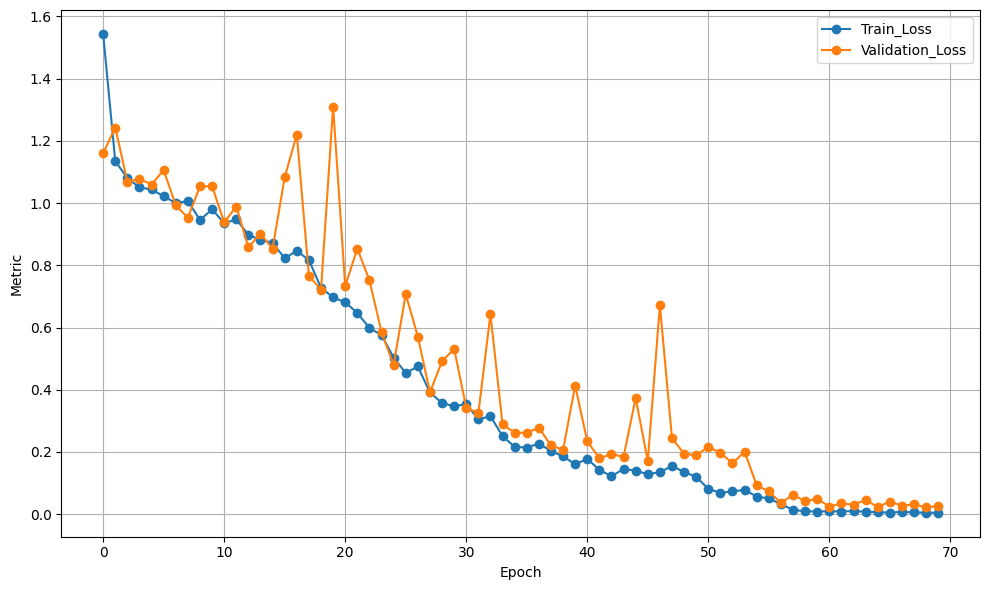

before_head_finetune
  image_roc_auc_raw: 0.9823369565217391
  image_avg_precision_raw: 0.9941805813234383
  image_roc_auc_sigmoid: 0.9823369565217391
  image_avg_precision_sigmoid: 0.9941805813234383
  pixel_roc_auc: 0.9799550304317496
  pixel_avg_precision: 0.5119630854169172
  num_images: 62
  num_good: 16
  num_anomaly: 46


In [9]:
baseline_model, baseline_train_info = load_or_train_base_model()
baseline_metrics, baseline_rows = evaluate_model(
    baseline_model,
    holdout_dataset,
    out_dir=log_dir,
    run_name="before_head_finetune",
    device=device,
    max_visualizations_per_group=max_visualizations_per_group,
)

baseline_state = {key: value.detach().cpu().clone() for key, value in baseline_model.state_dict().items()}
del baseline_model
torch.cuda.empty_cache()

## Fine-tune только classification head

Этот режим соответствует слабой разметке: есть нормальные/аномальные изображения, но маски не используются. Заморожены feature extractor, adaptor и segmentation head; обучаются только `segdec.cls_conv` и `segdec.cls_fc`.

In [10]:
def build_model_from_state(state_dict):
    model = SupersimplenetModel(
        backbone="wide_resnet50_2.tv_in1k",
        layers=["layer2", "layer3"],
        perlin_threshold=0.2,
        stop_grad=True,
    )
    model.load_state_dict(state_dict, strict=True)
    return model


def set_only_classifier_head_trainable(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.segdec.cls_conv.parameters():
        param.requires_grad = True
    for param in model.segdec.cls_fc.parameters():
        param.requires_grad = True
    get_trainable_parameters(model)


def classifier_head_logits(model, images):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)
    _, pred_score = model.segdec(adapted.detach())
    return pred_score.view(-1)


def finetune_classifier_head(
    model,
    dataset,
    num_epochs=6,
    learning_rate=3e-5,
    weight_decay=1e-4,
    batch_size=8,
    device=device,
    log_dir=log_dir,
):
    model = model.to(device)
    set_only_classifier_head_trainable(model)
    head_log_dir = Path(log_dir) / "classification_head_finetune"
    head_log_dir.mkdir(parents=True, exist_ok=True)

    labels = [float(item["label"]) for item in dataset.items]
    normal_count = max(1, sum(1 for label in labels if label == 0.0))
    anomaly_count = max(1, sum(1 for label in labels if label == 1.0))
    pos_weight = torch.tensor([normal_count / anomaly_count], device=device)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)

    metrics = {"Head_Train_Loss": []}
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.seg_head.eval()
        model.segdec.cls_conv.train()
        model.segdec.cls_fc.train()

        total_loss = 0.0
        for images, labels, _, _, _ in tqdm(loader, desc=f"Cls Head {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device).view(-1)

            optimizer.zero_grad()
            logits = classifier_head_logits(model, images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / max(1, len(loader))
        metrics["Head_Train_Loss"].append(avg_loss)
        print(f"Classification head epoch {epoch + 1}/{num_epochs} | loss={avg_loss:.6f}")

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
        }, head_log_dir / "checkpoint.pth")

    torch.save(model, head_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), head_log_dir / "trained_model_weights.pth")
    plot_training_curves([metrics["Head_Train_Loss"]], ["Head_Train_Loss"], head_log_dir, "head_loss.png")
    return model, metrics

Trainable parameters: 4919043
Trainable parameters: 4919043


Classification head epoch 1/6 | loss=0.977574


Classification head epoch 2/6 | loss=1.022607


Classification head epoch 3/6 | loss=0.703002


Classification head epoch 4/6 | loss=0.604685


Classification head epoch 5/6 | loss=0.603421


Classification head epoch 6/6 | loss=0.410225


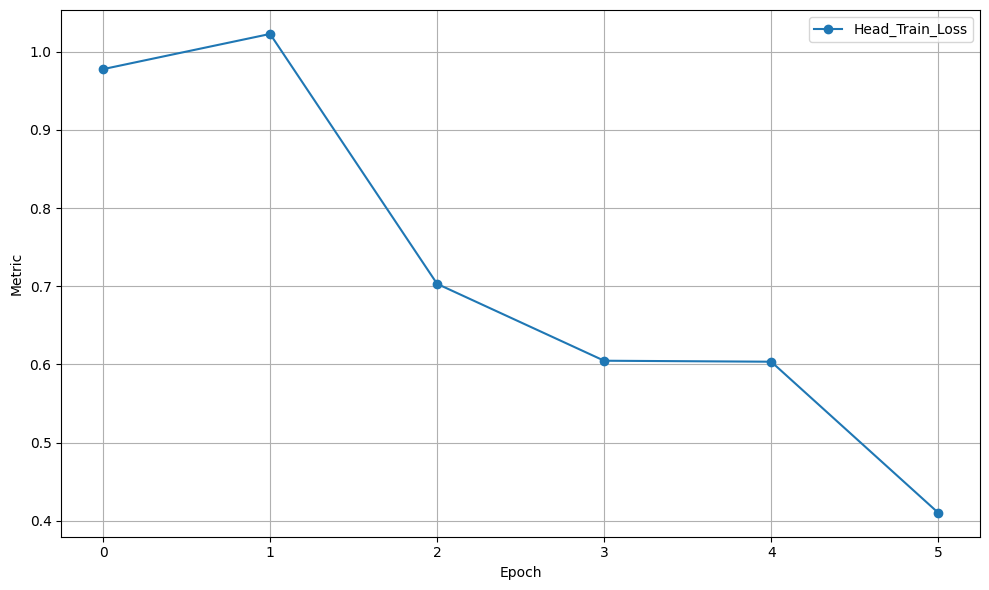

after_classification_head_finetune
  image_roc_auc_raw: 1.0
  image_avg_precision_raw: 0.9999999999999999
  image_roc_auc_sigmoid: 1.0
  image_avg_precision_sigmoid: 0.9999999999999999
  pixel_roc_auc: 0.9799550304317496
  pixel_avg_precision: 0.5119630854169172
  num_images: 62
  num_good: 16
  num_anomaly: 46


In [11]:
classification_head_model = build_model_from_state(baseline_state)
classification_head_model, classification_head_train_metrics = finetune_classifier_head(
    model=classification_head_model,
    dataset=head_cls_dataset,
    num_epochs=classification_head_epochs,
    learning_rate=classification_head_lr,
    weight_decay=classification_head_weight_decay,
    batch_size=classification_head_batch_size,
    device=device,
    log_dir=log_dir,
)

classification_head_metrics, classification_head_rows = evaluate_model(
    classification_head_model,
    holdout_dataset,
    out_dir=log_dir,
    run_name="after_classification_head_finetune",
    device=device,
    max_visualizations_per_group=max_visualizations_per_group,
)

del classification_head_model
torch.cuda.empty_cache()

## Fine-tune segmentation + classification heads на масках

Этот режим ближе к mixed / fully supervised: feature extractor и adaptor остаются заморожены, но весь `segdec` блок дообучается на реальных масках. Если `use_synthetic_during_mask_finetune=True`, то к реальным маскам добавляются синтетические латентные аномалии вне дефектных областей, как в SuperSimpleNet supervised-режиме.

In [12]:
def set_only_segdec_trainable(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.segdec.parameters():
        param.requires_grad = True
    get_trainable_parameters(model)


def forward_mask_finetune_loss_path(model, images, masks, labels, criterion, device, use_synthetic=True):
    with torch.no_grad():
        features = model.feature_extractor(images)
        adapted = model.adaptor(features)

    masks = masks.squeeze(1) if masks.ndim == 4 else masks
    target_mask = model.downsample_mask(masks, *adapted.shape[-2:])
    target_label = labels.to(torch.float32).view(-1)

    if use_synthetic:
        train_features, target_mask, target_label = model.anomaly_generator(
            adapted.detach(),
            target_mask,
            target_label,
        )
    else:
        train_features = adapted.detach()

    pred_map, pred_score = model.segdec(train_features)
    pred_score = pred_score.view(-1)
    target_label = target_label.view(-1)
    return criterion(pred_map=pred_map, pred_score=pred_score, target_mask=target_mask, target_label=target_label)


def finetune_segdec_heads_with_masks(
    model,
    dataset,
    num_epochs=8,
    learning_rate=2e-5,
    weight_decay=1e-5,
    batch_size=6,
    device=device,
    log_dir=log_dir,
    use_synthetic=True,
):
    model = model.to(device)
    set_only_segdec_trainable(model)
    head_log_dir = Path(log_dir) / "segdec_mask_finetune"
    head_log_dir.mkdir(parents=True, exist_ok=True)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    criterion = SSNLoss()
    optimizer = optim.AdamW(get_trainable_parameters(model), lr=learning_rate, weight_decay=weight_decay)
    scheduler = MultiStepLR(
        optimizer,
        milestones=[max(1, int(num_epochs * 0.75)), max(1, int(num_epochs * 0.9))],
        gamma=0.4,
    )

    metrics = {"SegDec_Train_Loss": []}
    for epoch in range(num_epochs):
        model.train()
        model.feature_extractor.eval()
        model.adaptor.eval()
        model.segdec.train()

        total_loss = 0.0
        for images, labels, masks, _, _ in tqdm(loader, desc=f"SegDec Head {epoch + 1}/{num_epochs}", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            loss = forward_mask_finetune_loss_path(
                model,
                images,
                masks,
                labels,
                criterion,
                device,
                use_synthetic=use_synthetic,
            )
            loss.backward()
            clip_grad_norm_(model.segdec.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / max(1, len(loader))
        metrics["SegDec_Train_Loss"].append(avg_loss)
        print(f"SegDec epoch {epoch + 1}/{num_epochs} | loss={avg_loss:.6f}")

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "metrics": metrics,
        }, head_log_dir / "checkpoint.pth")

    torch.save(model, head_log_dir / "trained_model.pth")
    torch.save(model.state_dict(), head_log_dir / "trained_model_weights.pth")
    plot_training_curves([metrics["SegDec_Train_Loss"]], ["SegDec_Train_Loss"], head_log_dir, "segdec_loss.png")
    return model, metrics

Trainable parameters: 6496003
Trainable parameters: 6496003


SegDec epoch 1/8 | loss=0.135284


SegDec epoch 2/8 | loss=0.110097


SegDec epoch 3/8 | loss=0.066162


SegDec epoch 4/8 | loss=0.060690


SegDec epoch 5/8 | loss=0.050312


SegDec epoch 6/8 | loss=0.048879


SegDec epoch 7/8 | loss=0.043777


SegDec epoch 8/8 | loss=0.043487


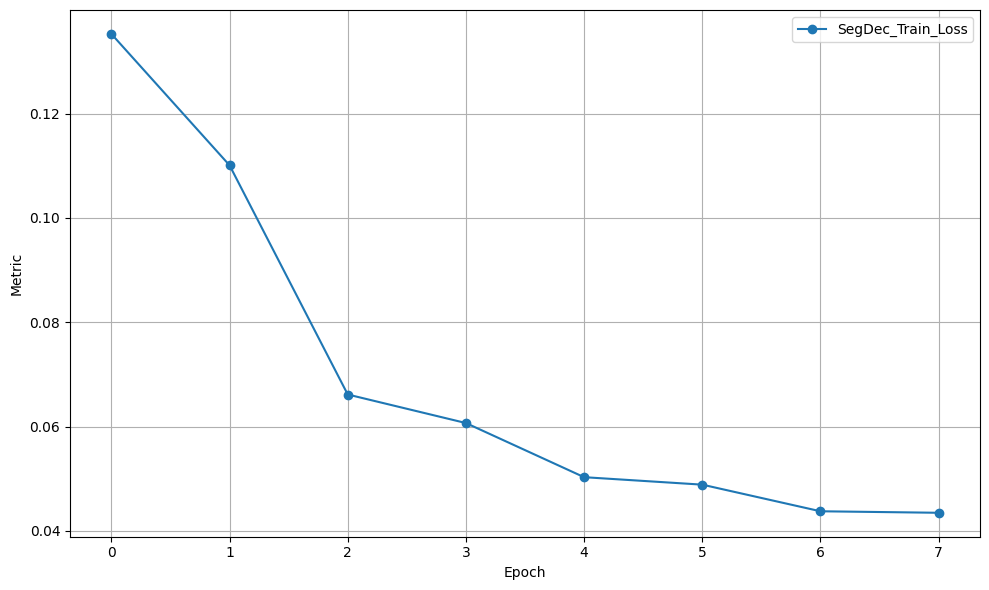

after_segdec_mask_finetune
  image_roc_auc_raw: 0.9972826086956522
  image_avg_precision_raw: 0.9990942028985506
  image_roc_auc_sigmoid: 0.9972826086956522
  image_avg_precision_sigmoid: 0.9990942028985506
  pixel_roc_auc: 0.9893924705150515
  pixel_avg_precision: 0.7592433526399905
  num_images: 62
  num_good: 16
  num_anomaly: 46


In [13]:
if run_segdec_mask_finetune:
    segdec_head_model = build_model_from_state(baseline_state)
    segdec_head_model, segdec_head_train_metrics = finetune_segdec_heads_with_masks(
        model=segdec_head_model,
        dataset=head_mask_dataset,
        num_epochs=segdec_head_epochs,
        learning_rate=segdec_head_lr,
        weight_decay=segdec_head_weight_decay,
        batch_size=segdec_head_batch_size,
        device=device,
        log_dir=log_dir,
        use_synthetic=use_synthetic_during_mask_finetune,
    )

    segdec_head_metrics, segdec_head_rows = evaluate_model(
        segdec_head_model,
        holdout_dataset,
        out_dir=log_dir,
        run_name="after_segdec_mask_finetune",
        device=device,
        max_visualizations_per_group=max_visualizations_per_group,
    )

    del segdec_head_model
    torch.cuda.empty_cache()
else:
    segdec_head_metrics = None

## Сравнение

Главная проверка гипотезы:
- если растут `image_roc_auc_raw` / `image_avg_precision_raw` после `classification_head_finetune`, значит отдельная калибровка classification head помогает как в продовом ноутбуке;
- если растут `pixel_roc_auc` / `pixel_avg_precision` после `segdec_mask_finetune`, значит при наличии масок стоит дообучать не только classification head, но и segmentation head;
- если baseline уже около 1.0 на выбранном классе, лучше повторить на более сложном классе MVTec или уменьшить долю fine-tune дефектов.

In [14]:
def compare_metrics(metric_sets, out_dir):
    out_dir = Path(out_dir)
    rows = []
    baseline = metric_sets["before_head_finetune"]
    metric_names = [
        "image_roc_auc_raw",
        "image_avg_precision_raw",
        "pixel_roc_auc",
        "pixel_avg_precision",
    ]

    for run_name, metrics in metric_sets.items():
        row = {"run_name": run_name}
        for metric_name in metric_names:
            value = metrics.get(metric_name, float("nan"))
            row[metric_name] = value
            row[f"delta_{metric_name}"] = value - baseline.get(metric_name, float("nan"))
        rows.append(row)

    with open(out_dir / "comparison_metrics.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    with open(out_dir / "comparison_metrics.json", "w") as f:
        json.dump(rows, f, indent=2)

    for row in rows:
        print(row["run_name"])
        for key, value in row.items():
            if key != "run_name":
                print(f"  {key}: {value}")
    return rows


metric_sets = {
    "before_head_finetune": baseline_metrics,
    "after_classification_head_finetune": classification_head_metrics,
}
if segdec_head_metrics is not None:
    metric_sets["after_segdec_mask_finetune"] = segdec_head_metrics

comparison_rows = compare_metrics(metric_sets, log_dir)
print(f"Artifacts saved to: {log_dir.resolve()}")

before_head_finetune
  image_roc_auc_raw: 0.9823369565217391
  delta_image_roc_auc_raw: 0.0
  image_avg_precision_raw: 0.9941805813234383
  delta_image_avg_precision_raw: 0.0
  pixel_roc_auc: 0.9799550304317496
  delta_pixel_roc_auc: 0.0
  pixel_avg_precision: 0.5119630854169172
  delta_pixel_avg_precision: 0.0
after_classification_head_finetune
  image_roc_auc_raw: 1.0
  delta_image_roc_auc_raw: 0.017663043478260865
  image_avg_precision_raw: 0.9999999999999999
  delta_image_avg_precision_raw: 0.00581941867656155
  pixel_roc_auc: 0.9799550304317496
  delta_pixel_roc_auc: 0.0
  pixel_avg_precision: 0.5119630854169172
  delta_pixel_avg_precision: 0.0
after_segdec_mask_finetune
  image_roc_auc_raw: 0.9972826086956522
  delta_image_roc_auc_raw: 0.014945652173913082
  image_avg_precision_raw: 0.9990942028985506
  delta_image_avg_precision_raw: 0.004913621575112215
  pixel_roc_auc: 0.9893924705150515
  delta_pixel_roc_auc: 0.00943744008330194
  pixel_avg_precision: 0.7592433526399905
  delt